In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as mp

import subprocess as sp
import glob as glob


case =  f.e22.FHIST.f09_f09.cesm2_2.mcont_mjo.001
/glade/derecho/scratch/rneale/archive_cheyenne/f.e22.FHIST.f09_f09.cesm2_2.mcont_mjo.001/atm/hist/f.e22.FHIST.f09_f09.cesm2_2.mcont_mjo.001.cam.h1.1990-01-06-00000.nc
/glade/derecho/scratch/rneale/archive_cheyenne/f.e22.FHIST.f09_f09.cesm2_2.mcont_mjo.001/atm/hist/f.e22.FHIST.f09_f09.cesm2_2.mcont_mjo.001.cam.h1.1999-12-17-00000.nc
<xarray.DataArray 'strftime' (time: 1200)>
array(['February', 'February', 'February', ..., 'May', 'May', 'May'],
      dtype=object)
Coordinates:
  * time     (time) object 1990-02-01 00:00:00 ... 1999-05-31 00:00:00
[0, 0.1, 0.2, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 40]

case =  f.e20.FHIST.f09_f09.cesm2_1_reynolds_daily_sst.006
/glade/campaign/cgd/amp/amwg/runs/f.e20.FHIST.f09_f09.cesm2_1_reynolds_daily_sst.006/atm/hist/f.e20.FHIST.f09_f09.cesm2_1_reynolds_daily_sst.006.cam.h1.1990-01-26-00000.nc
/glade/campaign/cgd/amp/amwg/runs/f.e20.FHIST.f09_f09.cesm2_1_reynolds_daily_sst.006

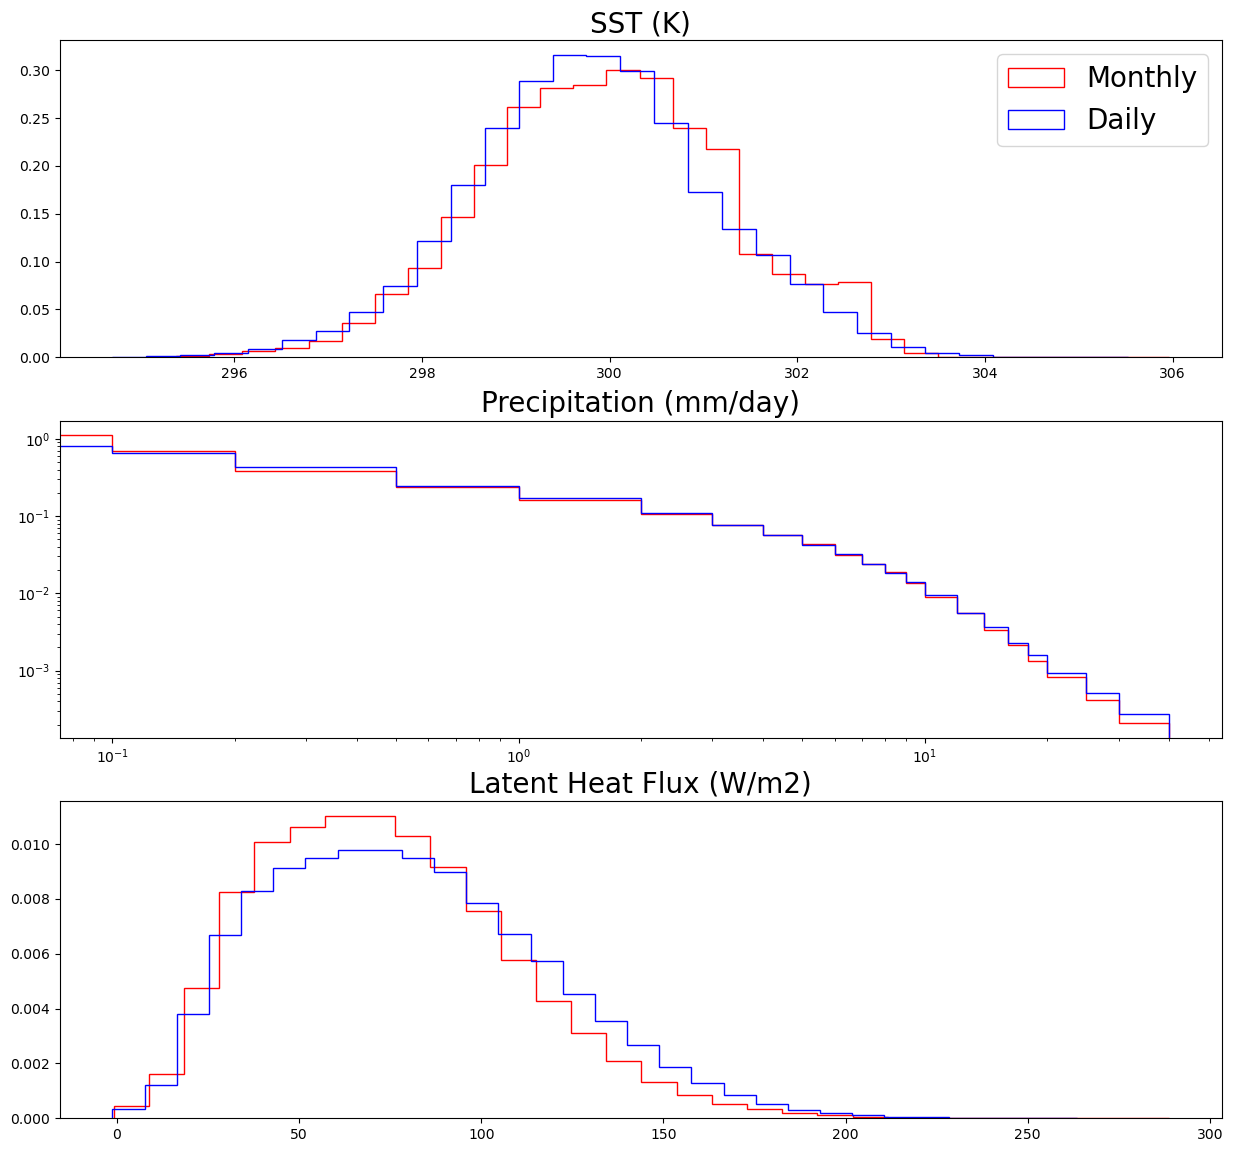

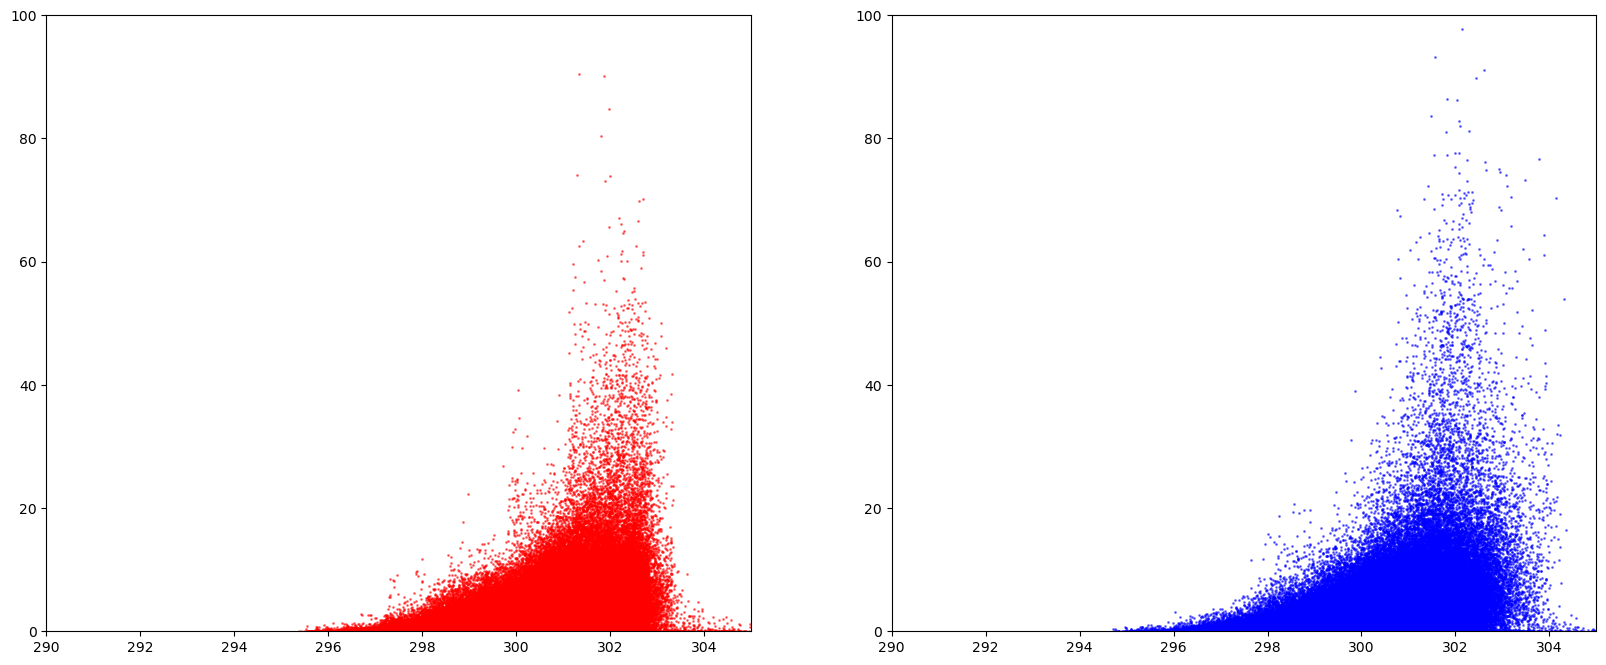

In [3]:
cases = ['f.e22.FHIST.f09_f09.cesm2_2.mcont_mjo.001','f.e20.FHIST.f09_f09.cesm2_1_reynolds_daily_sst.006']
case_names = ['Monthly','Daily']
in_dirs = ['/glade/derecho/scratch/rneale/archive_cheyenne/','/glade/campaign/cgd/amp/amwg/runs/']

xdom = [225,270] 
ydom = [-5,0]

fig, (ax1,ax2,ax3) = mp.subplots(nrows=3, ncols=1,figsize=(15,14))
figs, axs = mp.subplots(nrows=1, ncols=2,figsize=(20,8))

imonths = [2,3,4,5]
colors = ['red', 'blue']

pbins=[0, 0.1,0.2,0.5,1,2,3,4,5,6,7,8,9, 10, 12, 14, 16, 18, 20, 25, 30, 40]

for ic,case in enumerate(cases):

    print('')
    print('case = ',case)
    
    in_dir_c = in_dirs[ic]+case+'/atm/hist/'    
    files_stub = in_dir_c+case+'.cam.h1.199'
   
    glob_cmd = 'ls -1 '+files_stub+'*nc'
    
    infiles_c = sorted(glob.glob(files_stub+'*nc'))
#    infiles_c =  sp.getoutput('ls '+files_stub+'*nc')
    print(infiles_c[0])
    print(infiles_c[-1])
 
       
    ds_run = xr.open_mfdataset(infiles_c)
    sst = ds_run['TS'].loc[:,ydom[0]:ydom[1],xdom[0]:xdom[1]]
    prect = ds_run['PRECT'].loc[:,ydom[0]:ydom[1],xdom[0]:xdom[1]]
    lhflx = ds_run['LHFLX'].loc[:,ydom[0]:ydom[1],xdom[0]:xdom[1]]

    sst = sst.sel(time=ds_run['time.month'].isin(imonths))
    prect = prect.sel(time=ds_run['time.month'].isin(imonths))
    lhflx = lhflx.sel(time=ds_run['time.month'].isin(imonths))

#    print(sst["time"].dt.strftime("%B"))
    
    prect = prect*86400*1000

    sst_1d = sst.values.ravel()
    prect_1d = prect.values.ravel()
    lhflx_1d = lhflx.values.ravel()  

    ax1.hist(sst_1d, 30, histtype='step', stacked=True, fill=False, density=True,color=colors[ic],label=case_names[ic])
    sst_mean,sst_var = np.mean(sst_1d), np.var(sst_1d)
    
    
    ax2.hist(prect_1d, bins=pbins, histtype='step', stacked=True, fill=False, density=True,log=True,color=colors[ic],label=case_names[ic])
    prect_mean,prect_var = np.mean(prect_1d), np.var(prect_1d)
    
    ax3.hist(lhflx_1d, 30, histtype='step', stacked=True, fill=False,density=True,color=colors[ic],label=case_names[ic])
    lhflx_mean,lhflx_var = np.mean(lhflx_1d), np.var(lhflx_1d)

    print(pbins)
    ax2.set_xscale('log')
    
#    ax2.xaxis.set_ticks(pbins)
#    ax2.xaxis.set_ticklabels(pbins) # change the ticks' names to x

# Scatter plots
   
    axs[ic].scatter(sst_1d, prect_1d, alpha=0.5,s=1,color=colors[ic])
    axs[ic].set_ylim((0,100.))
    axs[ic].set_xlim((290,305.))
    


ax1.set_title('SST (K)',fontsize=20)
ax2.set_title('Precipitation (mm/day)',fontsize=20)
ax3.set_title('Latent Heat Flux (W/m2)',fontsize=20)

ax1.legend(prop={'size': 20})





